# Paso 2: Ingeniería de Características (Feature Engineering)

La **Ingeniería de Características (Feature Engineering)** es el proceso de transformar y enriquecer los datos originales para construir variables que permitan a los algoritmos de Machine Learning aprender de manera más efectiva. Esta etapa es fundamental en cualquier proyecto de analítica predictiva, ya que la calidad de las características influye directamente en el desempeño del modelo.

En este notebook se cargarán los conjuntos de datos generados en el notebook **Ingesta de Datos** (`1_data_ingestion.ipynb`) y se combinarán para construir un único conjunto de datos con las variables necesarias para describir el comportamiento de las máquinas a lo largo del tiempo.

Durante el desarrollo del notebook se aplicarán diferentes técnicas de **ingeniería de características** y **etiquetado de datos (labeling)** para obtener un conjunto de datos listo para el entrenamiento de modelos de **Mantenimiento Predictivo**.

### Importación de librerías

En esta sección se importan las librerías necesarias para manipular los datos, realizar transformaciones y trabajar durante el proceso de ingeniería de características.

In [1]:
# =====================================
# Librerías estándar
# =====================================
from pathlib import Path
import time
import datetime

# =====================================
# Manipulación de datos
# =====================================
import numpy as np
import pandas as pd

# =====================================
# Visualización
# =====================================
import matplotlib.pyplot as plt

# Mostrar las gráficas dentro del notebook (opcional)
# %matplotlib inline

# =====================================
# Inicio del cronómetro
# =====================================
tic = time.time()

## Carga de los datos

En el notebook **Ingesta de Datos** (`1_data_ingestion.ipynb`) se descargaron, transformaron y prepararon los siguientes conjuntos de datos:

- **Machines:** Contiene las características de cada máquina, como su modelo y antigüedad.
- **Errors:** Registra los errores no críticos detectados durante la operación. Aunque no representan una falla inmediata, pueden ser indicadores de un posible fallo futuro.
- **Maint:** Almacena el historial de mantenimiento de las máquinas, incluyendo el reemplazo de componentes y las fechas en que se realizaron estas intervenciones.
- **Telemetry:** Contiene las variables operativas registradas por los sensores de cada máquina, como voltaje, presión, vibración y velocidad de rotación.
- **Failures:** Registra el historial de fallas ocurridas en las máquinas y el componente que presentó la falla.

El primer paso de este notebook consiste en cargar estos conjuntos de datos para utilizarlos en el proceso de **Ingeniería de Características**, donde se construirán las variables que servirán como entrada para el modelo de Machine Learning.


In [2]:
# Carpeta raíz del proyecto
BASE_PATH = Path.cwd().parent

# Carpetas del proyecto
INPUT_PATH = BASE_PATH / "data" / "input_data"
OUTPUT_PATH = BASE_PATH / "data" / "output_data"
MODEL_PATH = BASE_PATH / "models"

# Archivos de entrada
MACH_DATA = INPUT_PATH / "PdM_machines.csv"
ERROR_DATA = INPUT_PATH / "PdM_errors.csv"
MAINT_DATA = INPUT_PATH / "PdM_maint.csv"
TELEMETRY_DATA = INPUT_PATH / "PdM_telemetry.csv"
FAILURE_DATA = INPUT_PATH / "PdM_failures.csv"

# Archivo de salida
FEATURES_DATA = OUTPUT_PATH / "featureengineering_files.parquet"

# Cargar los conjuntos de datos
machines = pd.read_csv(MACH_DATA)
errors = pd.read_csv(ERROR_DATA)
maint = pd.read_csv(MAINT_DATA)
telemetry = pd.read_csv(TELEMETRY_DATA)
failures = pd.read_csv(FAILURE_DATA)

# Mostrar la cantidad de registros de cada conjunto de datos
print(f"Machines:   {machines.shape}")
print(f"Errors:     {errors.shape}")
print(f"Maint:      {maint.shape}")
print(f"Telemetry:  {telemetry.shape}")
print(f"Failures:   {failures.shape}")

Machines:   (100, 3)
Errors:     (3919, 3)
Maint:      (3286, 3)
Telemetry:  (876100, 6)
Failures:   (761, 3)


## Ingeniería de Características (Feature Engineering)

El proceso de **Ingeniería de Características** tiene como objetivo integrar las diferentes fuentes de datos para construir un único conjunto de variables que permita describir el estado operativo de cada máquina a lo largo del tiempo. El resultado será un conjunto de datos donde cada registro representa una observación de una máquina en un instante determinado, incluyendo tanto las variables predictoras como la etiqueta que se utilizará para entrenar el modelo de Machine Learning.

En un problema de **Mantenimiento Predictivo**, los datos históricos registrados con su respectiva marca de tiempo (*timestamp*) se utilizan para estimar el estado actual de un equipo y la probabilidad de que ocurra una falla en un horizonte de tiempo futuro. Este tipo de problema puede abordarse como una tarea de **clasificación** sobre datos de **series de tiempo**, ya que el objetivo es utilizar el comportamiento histórico de las variables para predecir la ocurrencia de una falla.

### Variables basadas en retardos (Lag Features)

Existen múltiples estrategias para construir características a partir de datos de series de tiempo. En este laboratorio, el primer paso consiste en dividir el periodo de observación en intervalos de tiempo, de forma que cada registro represente el estado de una máquina en un momento específico.

La unidad de tiempo utilizada para construir estas observaciones depende del problema de negocio. Puede expresarse en segundos, minutos, horas, días o incluso en otras unidades como ciclos de operación, kilómetros recorridos o número de transacciones.

Es importante destacar que la frecuencia con la que se registran los datos no tiene por qué coincidir con la frecuencia utilizada para el análisis. Por ejemplo, si un sensor registra una medición cada 10 segundos, utilizar todas esas observaciones podría generar un gran número de registros con información muy similar. En estos casos, resulta más útil resumir la información en intervalos de tiempo mayores, permitiendo capturar mejor las tendencias relevantes para el modelo.

Una vez definida la frecuencia de análisis, el siguiente paso consiste en construir variables que describan la evolución de las señales en el tiempo. Para ello se emplean **ventanas móviles (Rolling Windows)**, que calculan estadísticas utilizando las observaciones más recientes de cada máquina. El tamaño de esta ventana, denotado por **W**, constituye un hiperparámetro que puede ajustarse durante el desarrollo del modelo.

La siguiente figura ilustra el funcionamiento de una **ventana móvil**, donde cada nueva observación incorpora la información de las tres observaciones anteriores para calcular una característica agregada.

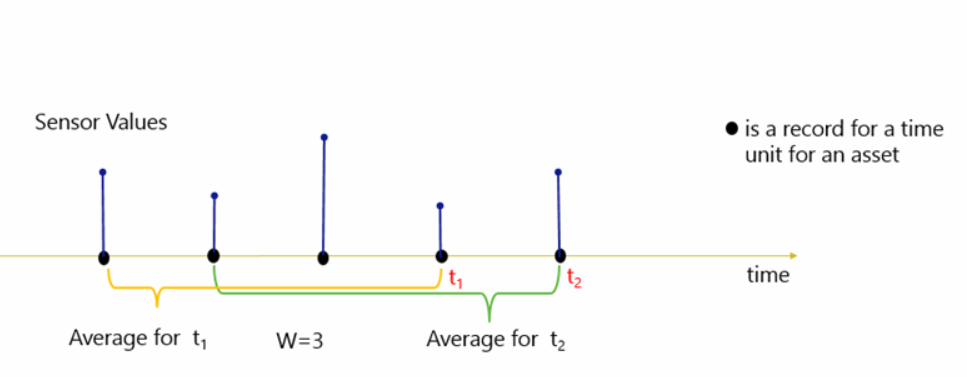

Las ventanas móviles permiten calcular diferentes estadísticas, entre ellas:

- Promedio (media).
- Desviación estándar.
- Conteo de eventos.
- Valores mínimos y máximos.
- Detección de valores atípicos.
- Otras métricas acumuladas de interés.

Otra estrategia ampliamente utilizada es el empleo de **ventanas agrupadas (Tumbling Windows)**. En este caso, las observaciones se agrupan en intervalos de tiempo fijos e independientes. Por ejemplo, aunque los sensores registren información cada 6 o 12 horas, puede ser conveniente construir características resumidas por día o por semana.

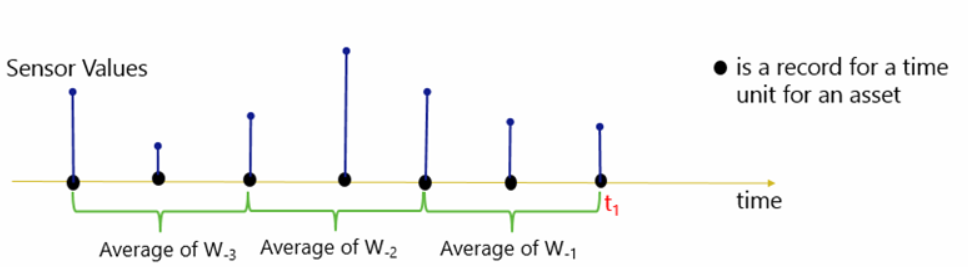

En este laboratorio se utilizará principalmente la estrategia de **ventanas móviles**, ya que permite capturar la evolución reciente del comportamiento de cada máquina y construir variables que servirán como entrada para el modelo de Mantenimiento Predictivo. El proceso comenzará con la generación de características a partir de los datos de **telemetría**.


## Características de Telemetría

Dado que el conjunto de datos de **telemetría** es la fuente con el mayor volumen de información y contiene las mediciones registradas por los sensores de las máquinas a lo largo del tiempo, el proceso de ingeniería de características comienza con este conjunto de datos.

Para reducir la cantidad de observaciones y facilitar el procesamiento, las mediciones se agrupan en **intervalos de 12 horas**, calculando el valor promedio de cada variable dentro de cada intervalo. Esta agregación disminuye el tamaño del conjunto de datos y reduce el tiempo requerido para las etapas posteriores de ingeniería de características, construcción de etiquetas y entrenamiento de modelos.

Una vez obtenidas las observaciones agregadas, se generan características temporales utilizando **ventanas móviles (Rolling Windows)**. Estas características resumen el comportamiento reciente de cada variable de telemetría y permiten capturar tendencias que pueden estar asociadas con una futura falla del equipo.

En este laboratorio se calcularán estadísticas como la **media** y la **desviación estándar** para las variables de telemetría utilizando ventanas móviles de **12, 24 y 36 horas**, representando así el comportamiento de corto plazo de las señales registradas por los sensores.


In [3]:
# Variables de interés
rolling_features = ["volt", "rotate", "pressure", "vibration"]

# Trabajar sobre una copia del conjunto de telemetría
tel_mean = telemetry.copy()

# Convertir la columna de fecha al tipo datetime
tel_mean["datetime"] = pd.to_datetime(tel_mean["datetime"])

# Intervalo de agregación (12 horas)
time_val = "12h"

In [4]:
rolling_features = ["volt", "rotate", "pressure", "vibration"]

telemetry = telemetry.sort_values(["machineID", "datetime"])

for lag in [12, 24, 36]:
    for feature in rolling_features:
        telemetry[f"{feature}_rollingmean_{lag}"] = (
            telemetry
            .groupby("machineID")[feature]
            .transform(lambda x: x.rolling(lag, min_periods=1).mean())
        )

        telemetry[f"{feature}_rollingstd_{lag}"] = (
            telemetry
            .groupby("machineID")[feature]
            .transform(lambda x: x.rolling(lag, min_periods=1).std())
        )

telemetry = telemetry.fillna(0)

## Características de los Errores

Al igual que los datos de **telemetría**, los registros de **errores** incluyen una marca de tiempo (*timestamp*), lo que permite analizar su comportamiento a lo largo del tiempo. Sin embargo, existe una diferencia importante: los identificadores de error (**errorID**) son variables **categóricas**, por lo que no tiene sentido calcular estadísticas como el promedio sobre ellas.

En su lugar, se construyen características contabilizando el **número de ocurrencias de cada tipo de error** dentro de una ventana de tiempo determinada. De esta forma, cada registro refleja la frecuencia con la que se han presentado los diferentes errores en el periodo de observación reciente.

Finalmente, los conteos de errores se alinean con las observaciones de telemetría utilizando intervalos de **12 horas**, garantizando que todas las variables del conjunto de datos compartan la misma referencia temporal y puedan combinarse posteriormente en un único conjunto de características.


In [5]:
# Crear una columna para cada tipo de error (One-Hot Encoding)
error_ind = pd.get_dummies(
    errors,
    columns=["errorID"],
    prefix="",
    prefix_sep=""
)

# Contar los errores por máquina y fecha
error_ind = (
    error_ind
    .groupby(["machineID", "datetime"], as_index=False)
    [["error1", "error2", "error3", "error4", "error5"]]
    .sum()
)

# Unir con la telemetría
error_count = (
    telemetry.merge(
        error_ind,
        on=["machineID", "datetime"],
        how="left"
    )
    .fillna(0)
)

# Nos quedamos únicamente con la información de errores
error_count = error_count.drop(
    columns=["volt", "rotate", "pressure", "vibration"]
)

# Variables de error
error_features = [
    "error1",
    "error2",
    "error3",
    "error4",
    "error5"
]

# Calcular la media móvil de las últimas 24 observaciones
for feature in error_features:
    error_count[f"{feature}sum_rollingmean_24"] = (
        error_count
        .sort_values(["machineID", "datetime"])
        .groupby("machineID")[feature]
        .transform(lambda x: x.rolling(24, min_periods=1).mean())
    )

# Crear la fecha truncada (cada 12 horas)
error_count["dt_truncated"] = pd.to_datetime(
    error_count["datetime"]
).dt.floor("12h")

# Construir el dataset final de características
error_feat = (
    error_count
    .groupby(["machineID", "dt_truncated"], as_index=False)
    [[f"{c}sum_rollingmean_24" for c in error_features]]
    .mean()
)

print(error_feat.shape)

error_feat.head(10)

(73100, 7)


,machineID,dt_truncated,error1sum_rollingmean_24,error2sum_rollingmean_24,error3sum_rollingmean_24,error4sum_rollingmean_24,error5sum_rollingmean_24
0,1,2015-01-01 00:00:00,0.000000,0.0,0.000000,0.0,0.000000
1,1,2015-01-01 12:00:00,0.000000,0.0,0.000000,0.0,0.000000
2,1,2015-01-02 00:00:00,0.000000,0.0,0.000000,0.0,0.000000
3,1,2015-01-02 12:00:00,0.000000,0.0,0.000000,0.0,0.000000
4,1,2015-01-03 00:00:00,0.017361,0.0,0.000000,0.0,0.000000
5,1,2015-01-03 12:00:00,0.041667,0.0,0.013889,0.0,0.000000
6,1,2015-01-04 00:00:00,0.024306,0.0,0.041667,0.0,0.020833
7,1,2015-01-04 12:00:00,0.000000,0.0,0.027778,0.0,0.041667
8,1,2015-01-05 00:00:00,0.000000,0.0,0.000000,0.0,0.020833
9,1,2015-01-05 12:00:00,0.000000,0.0,0.000000,0.0,0.000000


## Días desde el último reemplazo (Mantenimiento)

El historial de **mantenimiento** constituye una de las fuentes de información más importantes en un problema de **Mantenimiento Predictivo**, ya que registra las fechas en las que cada componente de una máquina fue reemplazado.

A partir de estos registros es posible construir diferentes características, como el número de reemplazos realizados o el tiempo transcurrido desde el último mantenimiento de cada componente. En este laboratorio se utilizará esta última estrategia, ya que, en términos generales, se espera que la probabilidad de falla aumente a medida que un componente permanece más tiempo en operación.

La construcción de este tipo de variables requiere un tratamiento especial, pues no basta con aplicar agregaciones tradicionales sobre series de tiempo. Es necesario relacionar cada observación de la máquina con el último reemplazo registrado para cada componente y calcular el número de días transcurridos desde dicho evento.

En las siguientes secciones se calculará el número de días desde el último reemplazo para cada uno de los cuatro componentes de la máquina. Como primer paso, se contabilizarán los reemplazos registrados para cada componente en el historial de mantenimiento.


In [6]:
# Crear variables indicadoras para cada componente reemplazado
maint_replace = pd.get_dummies(
    maint,
    columns=["comp"],
    prefix="",
    prefix_sep=""
)

# Contar los reemplazos por máquina y fecha
maint_replace = (
    maint_replace
    .groupby(["machineID", "datetime"], as_index=False)
    [["comp1", "comp2", "comp3", "comp4"]]
    .sum()
)

# Renombrar la columna de fecha para evitar conflictos en los joins posteriores
maint_replace = maint_replace.rename(
    columns={"datetime": "datetime_maint"}
)

print(maint_replace.shape)

maint_replace.head(10)

(2528, 6)


,machineID,datetime_maint,comp1,comp2,comp3,comp4
0,1,2014-06-01 06:00:00,0,1,0,0
1,1,2014-07-16 06:00:00,0,0,0,1
2,1,2014-07-31 06:00:00,0,0,1,0
3,1,2014-12-13 06:00:00,1,0,0,0
4,1,2015-01-05 06:00:00,1,0,0,1
5,1,2015-01-20 06:00:00,1,0,1,0
6,1,2015-02-04 06:00:00,0,0,1,1
7,1,2015-02-19 06:00:00,0,0,1,0
8,1,2015-03-06 06:00:00,1,0,0,0
9,1,2015-03-21 06:00:00,1,0,0,0


Una vez identificados los eventos de mantenimiento, se construyen nuevas características calculando el **número de días transcurridos desde el último reemplazo** de cada componente.

Este procedimiento se repite de forma independiente para los cuatro componentes de la máquina y, posteriormente, los resultados se combinan para formar el conjunto de características de mantenimiento.

In [7]:
# Variables sobre las que se calcularán estadísticas móviles
rolling_features = ["volt", "rotate", "pressure", "vibration"]

# Ordenar los datos
tel_mean = telemetry.sort_values(["machineID", "datetime"]).copy()

# Convertir fecha
tel_mean["datetime"] = pd.to_datetime(tel_mean["datetime"])

# Ventanas móviles
lags = [12, 24, 36]

for lag in lags:
    for feature in rolling_features:

        tel_mean[f"{feature}_rollingmean_{lag}"] = (
            tel_mean
            .groupby("machineID")[feature]
            .transform(lambda x: x.rolling(lag, min_periods=1).mean())
        )

        tel_mean[f"{feature}_rollingstd_{lag}"] = (
            tel_mean
            .groupby("machineID")[feature]
            .transform(lambda x: x.rolling(lag, min_periods=1).std())
        )

In [8]:
tel_mean["dt_truncated"] = (
    tel_mean["datetime"]
    .dt.floor("12h")
)

In [9]:
telemetry_feat = (
    tel_mean
    .drop(columns=rolling_features)
    .fillna(0)
    .groupby(["machineID","dt_truncated"],as_index=False)
    .mean()
)

/tmp/ipykernel_4441/3137174972.py:6: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  .mean()


In [10]:
# Crear el DataFrame con los instantes de tiempo de la telemetría
telemetry_times = (
    telemetry_feat[["machineID", "dt_truncated"]]
    .rename(columns={"dt_truncated": "datetime_tel"})
    .copy()
)

telemetry_times["datetime_tel"] = pd.to_datetime(telemetry_times["datetime_tel"])

In [11]:
def calcular_componente(telemetry_times, maint_replace, componente):
    """
    Calcula los días transcurridos desde el último reemplazo
    de un componente para cada observación de telemetría.
    """

    # Filtrar únicamente los reemplazos del componente
    maint_comp = maint_replace[
        maint_replace[componente] == 1
    ].copy()

    maint_comp["datetime_maint"] = pd.to_datetime(
        maint_comp["datetime_maint"]
    )

    maint_comp = maint_comp.rename(
        columns={"datetime_maint": "datetime"}
    )

    # Join por machineID
    maint_tel = telemetry_times.merge(
        maint_comp[["machineID", "datetime"]],
        on="machineID",
        how="inner"
    )

    # Mantener únicamente mantenimientos anteriores
    maint_tel = maint_tel[
        maint_tel["datetime_tel"] > maint_tel["datetime"]
    ]

    # Días desde el reemplazo
    maint_tel[f"sincelast{componente}"] = (
        maint_tel["datetime_tel"] -
        maint_tel["datetime"]
    ).dt.days

    return maint_tel.drop(columns="datetime")

In [12]:
comp1 = calcular_componente(telemetry_times, maint_replace, "comp1")
comp2 = calcular_componente(telemetry_times, maint_replace, "comp2")
comp3 = calcular_componente(telemetry_times, maint_replace, "comp3")
comp4 = calcular_componente(telemetry_times, maint_replace, "comp4")

print(comp1.shape)
print(comp2.shape)
print(comp3.shape)
print(comp4.shape)

(325390, 3)
(346254, 3)
(324164, 3)
(330698, 3)


Ejemplo de comp1!

In [13]:
comp1.head()

,machineID,datetime_tel,sincelastcomp1
0,1,2015-01-01 00:00:00,18
11,1,2015-01-01 12:00:00,19
22,1,2015-01-02 00:00:00,19
33,1,2015-01-02 12:00:00,20
44,1,2015-01-03 00:00:00,20


Ahora, combinamos las cuatro tablas de sustitución de componentes. Una vez combinadas, alineamos los datos aplicando una media móvil en ventanas de observación de 12 horas.

In [14]:
# Unir la información de los cuatro componentes
comps_feat = (
    comp1
    .merge(comp2, on=["machineID", "datetime_tel"], how="left")
    .merge(comp3, on=["machineID", "datetime_tel"], how="left")
    .merge(comp4, on=["machineID", "datetime_tel"], how="left")
)

# Reemplazar valores faltantes
comps_feat = comps_feat.fillna(0)

# Equivalente al groupBy + max() del notebook original
comps_feat = (
    comps_feat
    .groupby(
        ["machineID", "datetime_tel"],
        as_index=False
    )
    .agg({
        "sincelastcomp1": "max",
        "sincelastcomp2": "max",
        "sincelastcomp3": "max",
        "sincelastcomp4": "max"
    })
)

In [15]:
# Alinear la información en ventanas de 12 horas
comps_feat["dt_truncated"] = (
    pd.to_datetime(comps_feat["datetime_tel"])
    .dt.floor("12h")
)

# Construir el conjunto final de características de mantenimiento
maint_feat = (
    comps_feat
    .groupby(
        ["machineID", "dt_truncated"],
        as_index=False
    )
    .agg({
        "sincelastcomp1": "mean",
        "sincelastcomp2": "mean",
        "sincelastcomp3": "mean",
        "sincelastcomp4": "mean"
    })
    .rename(columns={
        "sincelastcomp1": "comp1sum",
        "sincelastcomp2": "comp2sum",
        "sincelastcomp3": "comp3sum",
        "sincelastcomp4": "comp4sum"
    })
)

print(maint_feat.shape)

maint_feat.head()

(73100, 6)


,machineID,dt_truncated,comp1sum,comp2sum,comp3sum,comp4sum
0,1,2015-01-01 00:00:00,18.0,213.0,153.0,168.0
1,1,2015-01-01 12:00:00,19.0,214.0,154.0,169.0
2,1,2015-01-02 00:00:00,19.0,214.0,154.0,169.0
3,1,2015-01-02 12:00:00,20.0,215.0,155.0,170.0
4,1,2015-01-03 00:00:00,20.0,215.0,155.0,170.0


## Variables de las máquinas

Las **características de las máquinas** corresponden a información descriptiva de cada equipo, la cual permanece constante en el tiempo. En este conjunto de datos se dispone de dos atributos principales:

- **Modelo de la máquina:** identifica el tipo o referencia del equipo.
- **Edad:** número de años que la máquina ha estado en operación.

La variable **edad** ya se encuentra en formato numérico, por lo que puede utilizarse directamente como característica del modelo de Machine Learning.

Por otro lado, la variable **modelo** es categórica y debe transformarse en un formato numérico. Para ello se aplicará la técnica de **One-Hot Encoding**, que convierte cada categoría en una variable binaria (0 o 1), permitiendo que el algoritmo de aprendizaje automático utilice esta información sin asumir un orden entre las categorías.

En esta práctica utilizaremos **One-Hot Encoding** para transformar la variable **modelo** y generar las características finales de las máquinas.


In [16]:
# Crear variables binarias (One-Hot Encoding) para la columna 'model'
machines_feat = pd.get_dummies(
    machines,
    columns=["model"],
    prefix="model",
    dtype=int
)

# Mostrar la cantidad de registros y las primeras filas
print(machines_feat.shape)

machines_feat.head(10)

(100, 6)


,machineID,age,model_model1,model_model2,model_model3,model_model4
0,1,18,0,0,1,0
1,2,7,0,0,0,1
2,3,8,0,0,1,0
3,4,7,0,0,1,0
4,5,2,0,0,1,0
5,6,7,0,0,1,0
6,7,20,0,0,1,0
7,8,16,0,0,1,0
8,9,7,0,0,0,1
9,10,10,0,0,1,0


## Integración de las características

Una vez generadas las características de **telemetría**, **mantenimiento**, **máquinas** y **errores**, el siguiente paso consiste en integrarlas en un único conjunto de datos.

Como la mayoría de las variables ya fueron alineadas previamente en intervalos de **12 horas**, la integración puede realizarse mediante operaciones de unión (*joins*) utilizando como claves el **identificador de la máquina (`machineID`)** y la **marca de tiempo (`dt_truncated`)**.

El resultado será un único conjunto de datos que reúne toda la información necesaria para el entrenamiento del modelo de **Mantenimiento Predictivo**, combinando las condiciones operativas de la máquina con su historial de mantenimiento, errores y características propias.


In [17]:
# Unir las características de errores con las de mantenimiento
error_maint = pd.merge(
    error_feat,
    maint_feat,
    on=["machineID", "dt_truncated"],
    how="left"
)

# Unir con las características de las máquinas
error_maint_feat = pd.merge(
    error_maint,
    machines_feat,
    on="machineID",
    how="left"
)

# Eliminar columnas que ya no son necesarias
error_maint_feat = error_maint_feat.drop(
    columns=[
        "error1sum",
        "error2sum",
        "error3sum",
        "error4sum",
        "error5sum"
    ],
    errors="ignore"
)

# Construir la matriz final de características
final_feat = pd.merge(
    telemetry_feat,
    error_maint_feat,
    on=["machineID", "dt_truncated"],
    how="left"
)

# Mostrar información del resultado
print(final_feat.shape)

final_feat[
    final_feat["machineID"] == 1
].sort_values("dt_truncated").head(10)

(73100, 40)


,machineID,dt_truncated,volt_rollingmean_12,volt_rollingstd_12,rotate_rollingmean_12,rotate_rollingstd_12,pressure_rollingmean_12,pressure_rollingstd_12,vibration_rollingmean_12,vibration_rollingstd_12,...,error5sum_rollingmean_24,comp1sum,comp2sum,comp3sum,comp4sum,age,model_model1,model_model2,model_model3,model_model4
0,1,2015-01-01 00:00:00,169.512597,6.239068,425.853115,46.581966,101.886267,13.166950,41.119335,4.473233,...,0.000000,18.0,213.0,153.0,168.0,18,0,0,1,0
1,1,2015-01-01 12:00:00,167.007032,8.260186,434.948972,50.000568,100.970047,10.863588,39.412711,5.716674,...,0.000000,19.0,214.0,154.0,169.0,18,0,0,1,0
2,1,2015-01-02 00:00:00,171.754734,13.479925,454.534311,44.925868,93.989345,7.963589,40.265190,5.761581,...,0.000000,19.0,214.0,154.0,169.0,18,0,0,1,0
3,1,2015-01-02 12:00:00,168.184995,15.356860,444.596343,39.260749,100.778017,10.107193,39.209928,5.957205,...,0.000000,20.0,215.0,155.0,170.0,18,0,0,1,0
4,1,2015-01-03 00:00:00,172.717240,12.879603,468.079805,40.727721,99.586915,12.005493,40.406556,5.574350,...,0.000000,20.0,215.0,155.0,170.0,18,0,0,1,0
5,1,2015-01-03 12:00:00,170.834194,12.090919,457.057988,41.703938,96.743024,9.012532,50.676883,7.265346,...,0.000000,21.0,216.0,156.0,171.0,18,0,0,1,0
6,1,2015-01-04 00:00:00,172.869308,14.466782,442.555398,42.292101,103.639622,9.550445,52.490685,5.627361,...,0.020833,21.0,216.0,156.0,171.0,18,0,0,1,0
7,1,2015-01-04 12:00:00,172.778379,21.972799,446.558222,34.547407,100.077137,10.305353,51.194922,4.392550,...,0.041667,22.0,217.0,157.0,172.0,18,0,0,1,0
8,1,2015-01-05 00:00:00,170.376832,19.677497,439.599809,39.904096,97.821329,8.926671,50.729673,7.290240,...,0.020833,22.0,217.0,157.0,172.0,18,0,0,1,0
9,1,2015-01-05 12:00:00,174.080665,14.994161,456.036474,49.178578,104.582541,11.473903,41.209276,6.588555,...,0.000000,23.0,218.0,158.0,173.0,18,0,0,1,0


# Construcción de las etiquetas

El **Mantenimiento Predictivo** es un problema de **aprendizaje supervisado**, por lo que es necesario contar con ejemplos de **fallas** y con el historial de observaciones que preceden a dichas fallas. De igual forma, el modelo también requiere ejemplos de periodos de operación normal para aprender a diferenciar entre un estado **saludable** y un estado **próximo a una falla**.

En un problema de clasificación, estas condiciones suelen representarse mediante una **etiqueta (label)** que indica el estado de la máquina.

Sin embargo, para que un sistema de mantenimiento predictivo sea realmente útil, no basta con identificar una falla cuando ya ocurrió. El objetivo es **anticiparla con suficiente tiempo** para que puedan ejecutarse acciones preventivas.

Por esta razón, la definición de la etiqueta se modifica. En lugar de marcar únicamente el instante exacto en el que ocurre una falla, se etiquetan también las observaciones registradas dentro de una **ventana de advertencia previa** (*warning window*). La duración de esta ventana depende de las necesidades del negocio. Por ejemplo:

- ¿Es suficiente anticipar una falla con **24 horas** de antelación?
- ¿Se requieren **7 días** para programar una intervención?
- ¿O es necesario un periodo aún mayor?

La elección de esta ventana influye directamente en el desempeño del modelo. Una ventana demasiado corta puede no proporcionar tiempo suficiente para actuar, mientras que una demasiado amplia puede introducir ruido y reducir la capacidad predictiva.

Para construir estas etiquetas, todas las observaciones que se encuentren dentro de la ventana previa a una falla se marcan con el componente que fallará. De esta forma, el problema se transforma en la estimación de la probabilidad de que una máquina presente una falla en un futuro cercano.

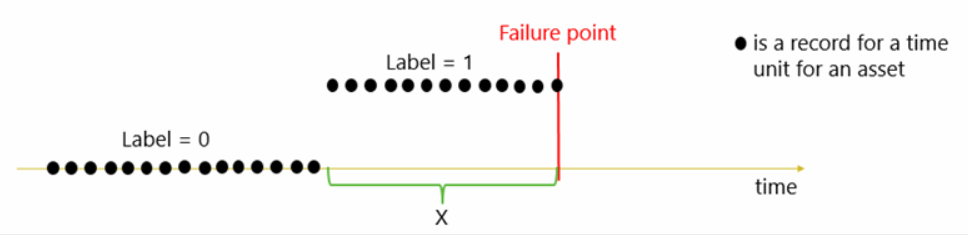

En este laboratorio, el objetivo será predecir la probabilidad de que una máquina falle en los **próximos 7 días** debido a la falla de alguno de sus cuatro componentes (**comp1**, **comp2**, **comp3** o **comp4**).

Se creará una variable categórica denominada **failure**, donde:

- **comp1**: la máquina fallará por el componente 1 dentro de la ventana de predicción.
- **comp2**: la máquina fallará por el componente 2 dentro de la ventana de predicción.
- **comp3**: la máquina fallará por el componente 3 dentro de la ventana de predicción.
- **comp4**: la máquina fallará por el componente 4 dentro de la ventana de predicción.
- **none**: no se espera ninguna falla durante la ventana definida.

El primer paso consiste en **alinear el historial de fallas con los instantes de observación del conjunto de características**, los cuales se encuentran organizados en intervalos de **12 horas**.


In [18]:
# Alinear las fechas de las fallas a intervalos de 12 horas
fail_diff = failures.copy()

fail_diff["datetime"] = pd.to_datetime(fail_diff["datetime"])

fail_diff["dt_truncated"] = (
    fail_diff["datetime"]
    .dt.floor("12h")
)

# Eliminar la columna original de fecha
fail_diff = fail_diff.drop(columns="datetime")

# Mostrar información del resultado
print(fail_diff.shape)

fail_diff.head(10)

(761, 3)


,machineID,failure,dt_truncated
0,1,comp4,2015-01-05
1,1,comp1,2015-03-06
2,1,comp2,2015-04-20
3,1,comp4,2015-06-19
4,1,comp4,2015-09-02
5,1,comp2,2015-10-17
6,1,comp4,2015-12-16
7,2,comp1,2015-03-19
8,2,comp2,2015-03-19
9,2,comp2,2015-04-18


## Conversión de las etiquetas a valores numéricos

Una vez definidas las etiquetas de falla, el siguiente paso consiste en transformarlas desde valores de texto a valores numéricos.

Inicialmente, la variable **failure** contiene categorías como **comp1**, **comp2**, **comp3**, **comp4** y **none**, donde esta última representa un estado de funcionamiento normal.

Para que el modelo de Machine Learning pueda utilizar esta información durante el entrenamiento, estas categorías se codifican en valores numéricos. De esta manera, el problema deja de representar únicamente dos estados (*saludable* o *próximo a una falla*) y se convierte en un problema de **clasificación multiclase**, donde el modelo deberá identificar cuál componente tiene mayor probabilidad de fallar dentro de la ventana de predicción establecida.

In [19]:
# Unir la matriz de características con las etiquetas de falla
labeled_features = pd.merge(
    final_feat,
    fail_diff,
    on=["machineID", "dt_truncated"],
    how="left"
)

# Convertir las etiquetas de texto a valores numéricos
failure_mapping = {
    "comp1": 1.0,
    "comp2": 2.0,
    "comp3": 3.0,
    "comp4": 4.0
}

labeled_features["failure"] = (
    labeled_features["failure"]
    .map(failure_mapping)
    .fillna(0.0)
    .astype(float)
)

# Mostrar información del resultado
print(labeled_features.shape)

labeled_features.head(10)

(73143, 41)


,machineID,dt_truncated,volt_rollingmean_12,volt_rollingstd_12,rotate_rollingmean_12,rotate_rollingstd_12,pressure_rollingmean_12,pressure_rollingstd_12,vibration_rollingmean_12,vibration_rollingstd_12,...,comp1sum,comp2sum,comp3sum,comp4sum,age,model_model1,model_model2,model_model3,model_model4,failure
0,1,2015-01-01 00:00:00,169.512597,6.239068,425.853115,46.581966,101.886267,13.166950,41.119335,4.473233,...,18.0,213.0,153.0,168.0,18,0,0,1,0,0.0
1,1,2015-01-01 12:00:00,167.007032,8.260186,434.948972,50.000568,100.970047,10.863588,39.412711,5.716674,...,19.0,214.0,154.0,169.0,18,0,0,1,0,0.0
2,1,2015-01-02 00:00:00,171.754734,13.479925,454.534311,44.925868,93.989345,7.963589,40.265190,5.761581,...,19.0,214.0,154.0,169.0,18,0,0,1,0,0.0
3,1,2015-01-02 12:00:00,168.184995,15.356860,444.596343,39.260749,100.778017,10.107193,39.209928,5.957205,...,20.0,215.0,155.0,170.0,18,0,0,1,0,0.0
4,1,2015-01-03 00:00:00,172.717240,12.879603,468.079805,40.727721,99.586915,12.005493,40.406556,5.574350,...,20.0,215.0,155.0,170.0,18,0,0,1,0,0.0
5,1,2015-01-03 12:00:00,170.834194,12.090919,457.057988,41.703938,96.743024,9.012532,50.676883,7.265346,...,21.0,216.0,156.0,171.0,18,0,0,1,0,0.0
6,1,2015-01-04 00:00:00,172.869308,14.466782,442.555398,42.292101,103.639622,9.550445,52.490685,5.627361,...,21.0,216.0,156.0,171.0,18,0,0,1,0,0.0
7,1,2015-01-04 12:00:00,172.778379,21.972799,446.558222,34.547407,100.077137,10.305353,51.194922,4.392550,...,22.0,217.0,157.0,172.0,18,0,0,1,0,0.0
8,1,2015-01-05 00:00:00,170.376832,19.677497,439.599809,39.904096,97.821329,8.926671,50.729673,7.290240,...,22.0,217.0,157.0,172.0,18,0,0,1,0,4.0
9,1,2015-01-05 12:00:00,174.080665,14.994161,456.036474,49.178578,104.582541,11.473903,41.209276,6.588555,...,23.0,218.0,158.0,173.0,18,0,0,1,0,0.0


## Verificación de las etiquetas de falla

Como paso final, es importante verificar que las etiquetas de falla hayan sido asignadas correctamente al conjunto de datos.

Para ello, se realiza un conteo de los registros pertenecientes a cada clase de la variable **failure**, lo que permite conocer la distribución de las observaciones entre el estado de funcionamiento normal (**0**) y las diferentes categorías de falla (**1**, **2**, **3** y **4**).

Esta verificación es útil para confirmar que el proceso de construcción de etiquetas se realizó correctamente y para identificar posibles desbalances entre las clases antes de entrenar el modelo de Machine Learning.

In [20]:
# Contar la cantidad de registros por clase de falla
labeled_features["failure"].value_counts().sort_index()

0.0    72382
1.0      192
2.0      259
3.0      131
4.0      179
Name: failure, dtype: int64

In [21]:
# Distribución de las clases de la variable objetivo
failure_distribution = (
    labeled_features["failure"]
    .value_counts()
    .sort_index()
    .rename_axis("Clase")
    .reset_index(name="Cantidad")
)

failure_distribution

,Clase,Cantidad
0,0.0,72382
1,1.0,192
2,2.0,259
3,3.0,131
4,4.0,179


## Conversión de eventos de falla a fallas inminentes

Hasta este punto, las etiquetas representan únicamente el **instante en el que ocurre una falla** (*failure events*).

Sin embargo, en un escenario de **Mantenimiento Predictivo** el objetivo no es detectar una falla cuando ya sucedió, sino anticiparla con suficiente tiempo para tomar acciones preventivas.

Para lograrlo, las etiquetas se amplían hacia atrás en el tiempo. Es decir, todas las observaciones registradas durante los **7 días anteriores** a una falla también se etiquetan como pertenecientes a esa falla.

De esta manera, el modelo aprenderá a identificar los patrones presentes antes de que ocurra el evento, transformando el problema de detectar una **falla ocurrida** a predecir una **falla inminente**.

In [22]:
# Ordenar por máquina y fecha descendente
labeled_features = labeled_features.sort_values(
    ["machineID", "dt_truncated"],
    ascending=[True, False]
).copy()

# Crear la etiqueta inicial
labeled_features["label"] = labeled_features["failure"]

# Propagar la información de falla hacia las 7 observaciones anteriores
for i in range(1, 8):
    labeled_features["label"] += (
        labeled_features
        .groupby("machineID")["failure"]
        .shift(i)
        .fillna(0)
    )

# Limitar las clases al rango 0-4
labeled_features["label_e"] = (
    labeled_features["label"]
    .clip(upper=4)
)

# Eliminar la columna auxiliar
labeled_features = labeled_features.drop(columns="label")

# Restaurar el orden cronológico
labeled_features = labeled_features.sort_values(
    ["machineID", "dt_truncated"]
).reset_index(drop=True)

print(labeled_features.shape)

labeled_features.head(10)

(73143, 42)


,machineID,dt_truncated,volt_rollingmean_12,volt_rollingstd_12,rotate_rollingmean_12,rotate_rollingstd_12,pressure_rollingmean_12,pressure_rollingstd_12,vibration_rollingmean_12,vibration_rollingstd_12,...,comp2sum,comp3sum,comp4sum,age,model_model1,model_model2,model_model3,model_model4,failure,label_e
0,1,2015-01-01 00:00:00,169.512597,6.239068,425.853115,46.581966,101.886267,13.166950,41.119335,4.473233,...,213.0,153.0,168.0,18,0,0,1,0,0.0,0.0
1,1,2015-01-01 12:00:00,167.007032,8.260186,434.948972,50.000568,100.970047,10.863588,39.412711,5.716674,...,214.0,154.0,169.0,18,0,0,1,0,0.0,4.0
2,1,2015-01-02 00:00:00,171.754734,13.479925,454.534311,44.925868,93.989345,7.963589,40.265190,5.761581,...,214.0,154.0,169.0,18,0,0,1,0,0.0,4.0
3,1,2015-01-02 12:00:00,168.184995,15.356860,444.596343,39.260749,100.778017,10.107193,39.209928,5.957205,...,215.0,155.0,170.0,18,0,0,1,0,0.0,4.0
4,1,2015-01-03 00:00:00,172.717240,12.879603,468.079805,40.727721,99.586915,12.005493,40.406556,5.574350,...,215.0,155.0,170.0,18,0,0,1,0,0.0,4.0
5,1,2015-01-03 12:00:00,170.834194,12.090919,457.057988,41.703938,96.743024,9.012532,50.676883,7.265346,...,216.0,156.0,171.0,18,0,0,1,0,0.0,4.0
6,1,2015-01-04 00:00:00,172.869308,14.466782,442.555398,42.292101,103.639622,9.550445,52.490685,5.627361,...,216.0,156.0,171.0,18,0,0,1,0,0.0,4.0
7,1,2015-01-04 12:00:00,172.778379,21.972799,446.558222,34.547407,100.077137,10.305353,51.194922,4.392550,...,217.0,157.0,172.0,18,0,0,1,0,0.0,4.0
8,1,2015-01-05 00:00:00,170.376832,19.677497,439.599809,39.904096,97.821329,8.926671,50.729673,7.290240,...,217.0,157.0,172.0,18,0,0,1,0,4.0,4.0
9,1,2015-01-05 12:00:00,174.080665,14.994161,456.036474,49.178578,104.582541,11.473903,41.209276,6.588555,...,218.0,158.0,173.0,18,0,0,1,0,0.0,0.0


## Verificación de la construcción de las etiquetas

Como paso de validación, se visualizarán las etiquetas generadas para un conjunto de **cuatro máquinas** a lo largo del periodo de observación.

Se espera que las etiquetas de cada componente aparezcan agrupadas en intervalos de tiempo, ya que todas las observaciones comprendidas dentro de la **ventana de predicción de 7 días** fueron etiquetadas como una **falla inminente**.

En la visualización se omiten los registros correspondientes al estado **normal** (etiqueta **0**), ya que representan la mayoría de las observaciones y no aportan información relevante para este análisis.

Debido a que la variable objetivo corresponde a un problema de **clasificación multiclase**, el gráfico mostrará cuatro niveles diferenciados en el eje **Y**, correspondientes a las clases:

- **1:** Falla inminente del componente 1.
- **2:** Falla inminente del componente 2.
- **3:** Falla inminente del componente 3.
- **4:** Falla inminente del componente 4.

Esta visualización permite comprobar que las etiquetas fueron propagadas correctamente dentro de la ventana de predicción definida.


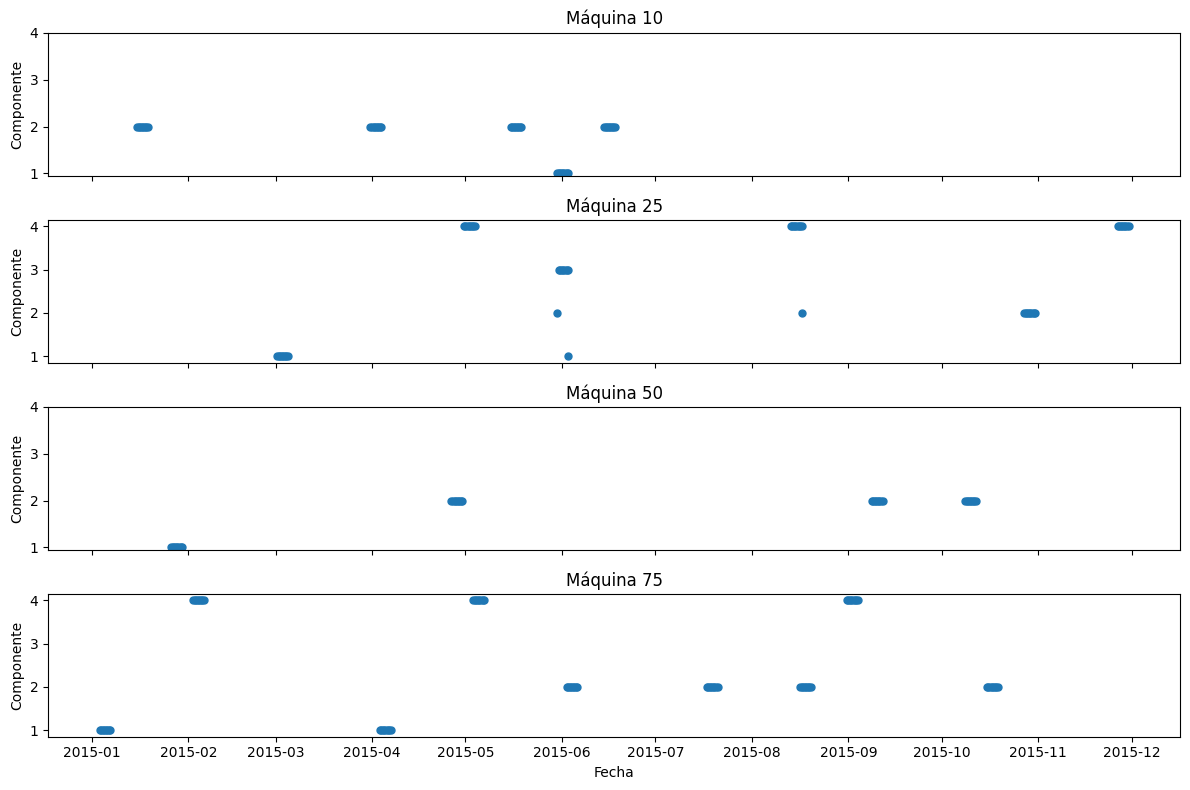

In [23]:
# Máquinas que se visualizarán
machines_to_plot = [10, 25, 50, 75]

# Filtrar únicamente las observaciones con falla
plt_dta = (
    labeled_features[
        (labeled_features["label_e"] > 0) &
        (labeled_features["machineID"].isin(machines_to_plot))
    ]
    .copy()
)

# Asegurar que la fecha tenga el formato correcto
plt_dta["dt_truncated"] = pd.to_datetime(plt_dta["dt_truncated"])

# Convertir las etiquetas a entero
plt_dta["label_e"] = plt_dta["label_e"].astype(int)

# Crear una figura con un gráfico por máquina
fig, axes = plt.subplots(
    len(machines_to_plot),
    1,
    figsize=(12, 8),
    sharex=True
)

for ax, machine in zip(axes, machines_to_plot):
    data = plt_dta[plt_dta["machineID"] == machine]

    ax.scatter(
        data["dt_truncated"],
        data["label_e"],
        s=25
    )

    ax.set_title(f"Máquina {machine}")
    ax.set_ylabel("Componente")

    ax.set_yticks([1, 2, 3, 4])

axes[-1].set_xlabel("Fecha")

plt.tight_layout()
plt.show()

## Interpretación de los resultados

En la gráfica se observa que la mayoría de las observaciones corresponden a un estado de **funcionamiento normal** (etiqueta **0**). Estas no se muestran para facilitar la visualización, aunque la línea de tiempo se mantiene completa.

Cada una de las máquinas seleccionadas presenta **múltiples eventos de falla** a lo largo del periodo de análisis. Para cada falla, no solo se etiqueta el instante en que ocurre el evento, sino también las observaciones registradas durante los **7 días anteriores**, las cuales reciben la misma etiqueta correspondiente al componente que fallará.

De esta forma, el modelo aprenderá a reconocer los patrones presentes antes de que ocurra una falla, en lugar de identificar únicamente el momento en que esta sucede.

El objetivo final será desarrollar un modelo capaz de predecir **cuándo es probable que ocurra una falla** y **qué componente será el responsable**. En consecuencia, este problema se aborda como una tarea de **clasificación multiclase**, donde cada clase representa la falla inminente de uno de los cuatro componentes. Como alternativa, también sería posible reformular el problema como cuatro modelos de **clasificación binaria**, uno para predecir la falla de cada componente de manera independiente.


## Almacenamiento del conjunto de datos final

Una vez finalizado el proceso de ingeniería de características y construcción de las etiquetas, el último paso consiste en guardar el conjunto de datos resultante para su uso en las siguientes etapas del proyecto.

En este laboratorio, el conjunto de datos final se almacenará en formato **Parquet**, un formato optimizado para el almacenamiento y procesamiento de grandes volúmenes de datos, ampliamente utilizado en entornos de analítica y Machine Learning.

In [24]:
# Crear la carpeta de salida si no existe
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

# Ruta del archivo
FEATURES_FILE = OUTPUT_PATH / "featureengineering_files.parquet"

# Guardar el conjunto de datos
labeled_features.to_parquet(FEATURES_FILE, index=False)

print("Proceso de Ingeniería de Características finalizado correctamente.")
print(f"Archivo guardado en: {FEATURES_FILE.resolve()}")
print("Este archivo será utilizado como entrada en el Notebook 3: Construcción del Modelo.")

Proceso de Ingeniería de Características finalizado correctamente.
Archivo guardado en: /mnt/batch/tasks/shared/LS_root/mounts/clusters/ci-pbi-demo/code/Users/expinvitado6/Proyecto/PredictiveMaintenance/data/output_data/featureengineering_files.parquet
Este archivo será utilizado como entrada en el Notebook 3: Construcción del Modelo.


# Conclusión

En este notebook se realizó el proceso de **Ingeniería de Características (Feature Engineering)**, transformando los datos originales de telemetría, errores, mantenimientos, fallas y características de las máquinas en un único conjunto de datos listo para el entrenamiento de modelos de Machine Learning.

Como resultado, se obtuvo un conjunto de datos enriquecido con variables predictoras y una etiqueta que identifica la ocurrencia de una falla inminente en alguno de los componentes de la máquina.

En el siguiente notebook, **`3_model_building.ipynb`**, se utilizará este conjunto de datos para entrenar y evaluar diferentes modelos de clasificación, con el objetivo de predecir de forma anticipada la ocurrencia de fallas en los equipos.